# Surrogate Model & Exploration Saturation Metric

A Random Forest surrogate trained on completed W&B runs to:
1. **Predict** expected scores for unexplored hyperparameter configurations
2. **Quantify exploration saturation** (ESM) — when to stop exploring a sub-space

In [1]:
import os
import itertools
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

from src.visualization import set_themes
from src.utils import get_kernel_id
from src.utils.config import parse_score_metric, Log10Transformer
from IPython.display import Markdown

from typing import List

set_themes()
pl.Config.set_tbl_rows(20)

polars.config.Config

## Configuration

Define the target metric, UCB exploration weight (β), and the discrete hyperparameter space to enumerate over.

In [2]:
run_summary_file = "wandb/summary.parquet"

# Target metric spec — same format as model_based_parse_parameters
# Single metric: "epoch/test_recall@20"
# Weighted composite: "epoch/test_recall@20:0.7 epoch/test_ndcg@20:0.3"
target_spec = "epoch/test_recall@20"
parsed_target = parse_score_metric(target_spec)
target_metric = "target"

# UCB exploration weight — shared with the downstream UCB search feature
beta = 1.0

# Hyperparameter columns to use as surrogate features.
# parameter_space (the list of discrete values per column) is derived automatically
# from completed runs in the Data Loading step below.
feature_names = [
    "embedding_dimension",
    "shuffle",
    "l1_regularization",
    "l2_regularization",
    "embedding_dropout_rate",
]

## Data Loading

Load completed runs from the local parquet cache produced by `wandb/sync.py`.

In [3]:
experiment_runs = pl.read_parquet(run_summary_file)
experiment_runs = experiment_runs.filter(pl.col("model") == "matrix_factorization")

# Compute target: best weighted composite score across epochs
# (same logic as model_based_parse_parameters in src/utils/config.py)
score_expression = sum(pl.col(m) * w for m, w in parsed_target.items())
experiment_runs = experiment_runs.with_columns(
    score_expression.list.max().alias(target_metric)
)

# Derive parameter_space from unique observed values per feature column
parameter_space = {}
for col in feature_names:
    unique_vals = sorted(experiment_runs[col].drop_nulls().unique().to_list())
    parameter_space[col] = unique_vals

total_space_size = 1
for values in parameter_space.values():
    total_space_size *= len(values)

print(f"Loaded {len(experiment_runs):,} runs")
print(f"Total joint parameter space: {total_space_size:,} configurations")
for col, vals in parameter_space.items():
    print(f"  {col}: {vals}")

experiment_runs.sort(
    pl.col(target_metric), descending=True
).select(
    pl.col("run_id"),
    pl.col("run_name"),
    *[pl.col(c) for c in feature_names],
    pl.col(target_metric),
)[:10]

Loaded 3,410 runs
Total joint parameter space: 20,000 configurations
  embedding_dimension: [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
  shuffle: [False, True]
  l1_regularization: [0.0, 1e-10, 1e-09, 1e-08, 1e-07, 1e-06, 1e-05, 0.0001, 0.001, 0.01]
  l2_regularization: [0.0, 1e-10, 1e-09, 1e-08, 1e-07, 1e-06, 1e-05, 0.0001, 0.001, 0.01]
  embedding_dropout_rate: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


run_id,run_name,embedding_dimension,shuffle,l1_regularization,l2_regularization,embedding_dropout_rate,target
str,str,i64,bool,f64,f64,f64,f64
"""kl4wqlfj""","""fallen-frost-6124""",1024,false,0.0000001,0.0000001,0.0,0.051081
"""06bqx7vi""","""spring-vortex-3451""",512,false,0.0000001,0.0000001,0.0,0.050881
"""ppnmplwp""","""light-vortex-4549""",512,false,0.0000001,0.0000001,0.0,0.050802
"""3f5jmpwt""","""crisp-sponge-5704""",512,false,0.0000001,0.0000001,0.0,0.050802
"""tc5m18b1""","""northern-wildflower-4878""",512,false,0.0000001,0.0000001,0.0,0.050787
"""th4pgbno""","""dark-elevator-3601""",512,false,0.0000001,0.0000001,0.0,0.050771
"""0287jiys""","""visionary-dust-4876""",512,false,0.0000001,0.0000001,0.0,0.050766
"""xznge89i""","""zesty-mountain-5325""",512,false,0.0000001,0.0000001,0.0,0.050763
"""yir89nn4""","""eager-lake-6123""",256,false,0.0000001,0.0000001,0.0,0.050755


## Data Preparation

Extract X (hyperparameter features) and y (best checkpoint score) from the loaded runs. Rows with missing target values are dropped.

- `shuffle` is cast to float (True → 1.0, False → 0.0)
- `l1_regularization` and `l2_regularization` are kept in raw scale here. The **log₁₀ transform** is applied inside the sklearn `Pipeline` as the first step, so the raw values flow cleanly through all data preparation and grid enumeration steps.

In [4]:
# Keep only rows that have all feature columns and the target metric
required_cols = feature_names + [target_metric]
full_dataframe = experiment_runs.select(required_cols).drop_nulls()

# Cast shuffle (boolean) to float so sklearn is happy
full_dataframe = full_dataframe.with_columns(pl.col("shuffle").cast(pl.Float64))

full_features = full_dataframe.select(feature_names).to_numpy()
full_target = full_dataframe[target_metric].to_numpy()

print(f"Training samples: {len(full_target):,}")
print(f"Target range:  [{full_target.min():.4f}, {full_target.max():.4f}]")
print(f"Target mean:   {full_target.mean():.4f}  ±  {full_target.std():.4f}")

Training samples: 3,410
Target range:  [0.0004, 0.0511]
Target mean:   0.0217  ±  0.0193


### Run Density per Parameter Region

Before choosing a leave-one-region-out holdout, check how many runs exist per value of each feature. A good holdout region should have:
- Enough runs to make the evaluation meaningful (≥ 10)
- Cover a range of target scores (not all zeros or all best)
- Not be at the extreme of the space (otherwise the surrogate has no neighbours to generalise from)

In [5]:
# Count runs and show mean target score per unique value of each feature
for col in feature_names:
    summary = (
        full_dataframe
        .group_by(col)
        .agg(
            pl.len().alias("n_runs"),
            pl.col(target_metric).mean().alias("mean_score"),
            pl.col(target_metric).std().alias("std_score"),
            pl.col(target_metric).min().alias("min_score"),
            pl.col(target_metric).max().alias("max_score"),
        )
        .sort(col)
    )
    print(f"\n── {col} ──")
    print(summary.to_pandas().to_string(index=False))


── embedding_dimension ──
 embedding_dimension  n_runs  mean_score  std_score  min_score  max_score
                   2     338    0.013443   0.011899   0.000426   0.029263
                   4     293    0.020028   0.015870   0.000413   0.037441
                   8     276    0.023532   0.018433   0.000449   0.043439
                  16     261    0.022943   0.019553   0.000413   0.047205
                  32     273    0.023265   0.020183   0.000412   0.049034
                  64     361    0.023460   0.020565   0.000410   0.049794
                 128     487    0.022675   0.020720   0.000437   0.050702
                 256     363    0.023330   0.020339   0.000415   0.050755
                 512     348    0.022360   0.020120   0.000420   0.050881
                1024     410    0.022223   0.020004   0.000398   0.051081

── shuffle ──
 shuffle  n_runs  mean_score  std_score  min_score  max_score
     0.0    2272    0.021474   0.019755   0.000398   0.051081
     1.0    1138    

## Surrogate Model Training

Fit a `RandomForestRegressor` on all completed runs.

- **μ̂** = mean prediction across trees (expected score)
- **σ̂** = std across trees (epistemic uncertainty)

`oob_score=True` gives an out-of-bag R² estimate without needing a held-out split.

In [5]:
# Acquisition surrogate: high tree diversity to give meaningful σ̂ signal
# min_samples_leaf=1 gives deeper trees → higher σ̂ on unexplored cells
surrogate = Pipeline([
    ("log_reg", Log10Transformer(feature_names)),
    ("rf", RandomForestRegressor(
        n_estimators=1024,
        max_features="sqrt",
        max_samples=0.1,
        min_samples_leaf=1,
        oob_score=True,
        n_jobs=-1,
        random_state=42,
    )),
])

surrogate.fit(full_features, full_target)
print(f"OOB R²: {surrogate.named_steps['rf'].oob_score_:.4f}")

OOB R²: 0.9946


## Model Evaluation — Leave-Cliff-Out

Proper holdout evaluation: train on all runs *except* those at or across the two performance cliffs, then predict on the held-out set.

The test set contains runs where:
- `l1_regularization ∈ {1e-7, 1e-6}` — the last good value and the first collapsed value of the l1 cliff
- OR `l2_regularization ∈ {1e-6, 1e-5}` — the last good value and the first collapsed value of the l2 cliff

This forces the surrogate to extrapolate across both discontinuities at once — the hardest possible test of whether it has learned the cliff structure.

Train size: 2,301  |  Test size (cliff runs): 1,109
Test target range: [0.0004, 0.0511]



Held-out R²:  0.9232
Held-out MAE: 0.0029


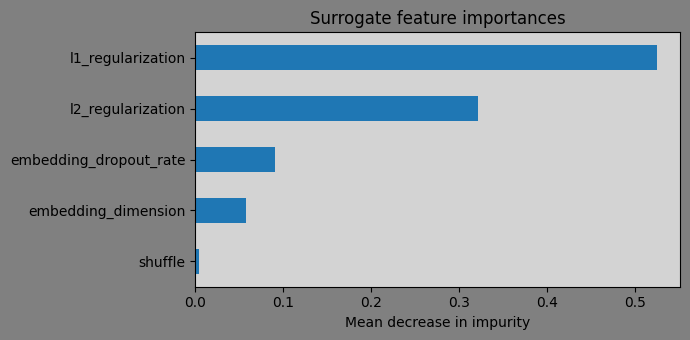

In [6]:
# Test set: runs at or across either performance cliff (raw scale — pipeline handles log transform)
mask_cliff = (
    full_dataframe["l1_regularization"].is_in([1e-7, 1e-6])
    | full_dataframe["l2_regularization"].is_in([1e-6, 1e-5])
)

train_dataframe = full_dataframe.filter(~mask_cliff)
test_dataframe  = full_dataframe.filter(mask_cliff)

train_features = train_dataframe.select(feature_names).to_numpy()
train_target   = train_dataframe[target_metric].to_numpy()
test_features  = test_dataframe.select(feature_names).to_numpy()
test_target    = test_dataframe[target_metric].to_numpy()

print(f"Train size: {len(train_dataframe):,}  |  Test size (cliff runs): {len(test_dataframe):,}")
print(f"Test target range: [{test_target.min():.4f}, {test_target.max():.4f}]")
print()

surrogate_eval = Pipeline([
    ("log_reg", Log10Transformer(feature_names)),
    ("rf", RandomForestRegressor(
        n_estimators=1024,
        max_features="sqrt",
        max_samples=0.1,
        min_samples_leaf=1,
        oob_score=False,
        n_jobs=-1,
        random_state=42,
    )),
])
surrogate_eval.fit(train_features, train_target)
predicted_target = surrogate_eval.predict(test_features)

print(f"Held-out R²:  {r2_score(test_target, predicted_target):.4f}")
print(f"Held-out MAE: {mean_absolute_error(test_target, predicted_target):.4f}")

# Feature importance plot (from the full-data surrogate)
fig, ax = plt.subplots(figsize=(7, 3.5))
importances = pd.Series(surrogate_eval.named_steps["rf"].feature_importances_, index=feature_names).sort_values(ascending=True)
importances.plot.barh(ax=ax)
ax.set_xlabel("Mean decrease in impurity")
ax.set_title("Surrogate feature importances")

plt.tight_layout()
plt.show()

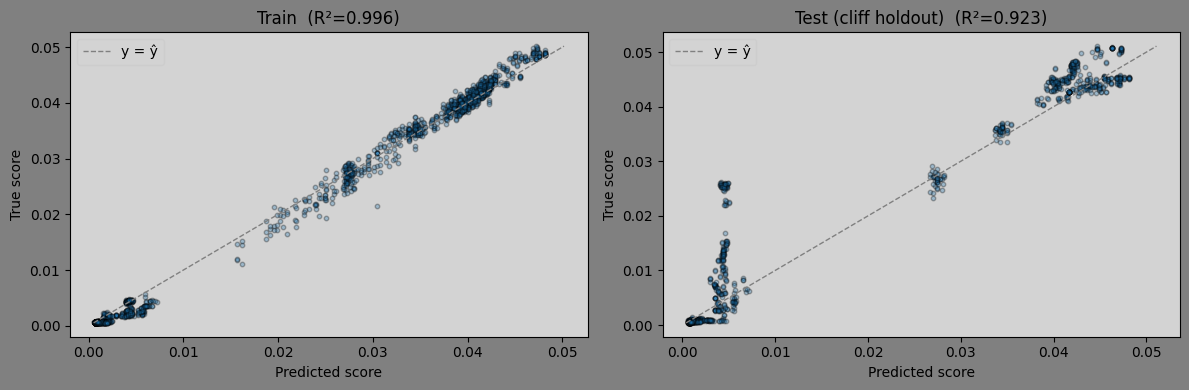

In [7]:
train_prediction = surrogate_eval.predict(train_features)
test_prediction  = surrogate_eval.predict(test_features)

axes: List[plt.Axes]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, ground_truth, prediction, label in [
    (axes[0], train_target, train_prediction, "Train"),
    (axes[1], test_target,  test_prediction,  "Test (cliff holdout)"),
]:
    ax.scatter(prediction, ground_truth, alpha=0.3, s=10)
    lo = min(ground_truth.min(), prediction.min())
    hi = max(ground_truth.max(), prediction.max())
    ax.plot([lo, hi], [lo, hi], "--", linewidth=1, label="y = ŷ", color="grey")
    ax.set_xlabel("Predicted score")
    ax.set_ylabel("True score")
    ax.set_title(f"{label}  (R²={r2_score(ground_truth, prediction):.3f})")
    ax.legend()

plt.tight_layout()
plt.show()

### μ̂ and σ̂ Distributions — Train vs. Test

Comparing the predicted mean (μ̂) and uncertainty (σ̂) distributions across the train and test splits.

- **Similar μ̂ distributions** → the surrogate generalises rather than memorising
- **Higher σ̂ on test** → the model correctly signals more uncertainty on less-seen configurations

> **Note:** The test set here is the **cliff holdout** (l1=1e-6/1e-7, l2=1e-5/1e-6) — these are runs held out from fitting but still in well-explored regions. The σ̂ separation is naturally smaller than the full unexplored grid check below (see **σ̂ Validation** section).

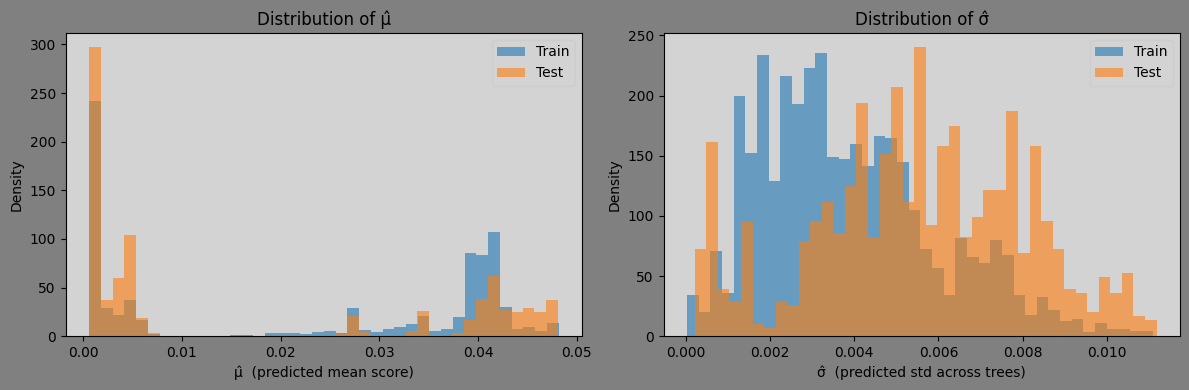

Test  — μ̂: 0.0172 ± 0.0191   σ̂: 0.0055 ± 0.0025
Train — μ̂: 0.0230 ± 0.0184   σ̂: 0.0039 ± 0.0021
σ̂ ratio (test / train): 1.43x  (cliff holdout — expect smaller than full unexplored grid)


In [8]:
# Compute per-tree predictions for train and test splits to get µ̂ and σ̂
rf_eval = surrogate_eval.named_steps["rf"]
log_train = surrogate_eval.named_steps["log_reg"].transform(train_features)
log_test  = surrogate_eval.named_steps["log_reg"].transform(test_features)
train_tree_predictions = np.stack([tree.predict(log_train) for tree in rf_eval.estimators_], axis=0)
test_tree_predictions  = np.stack([tree.predict(log_test)  for tree in rf_eval.estimators_], axis=0)

mu_train    = train_tree_predictions.mean(axis=0)
sigma_train = train_tree_predictions.std(axis=0)
mu_test     = test_tree_predictions.mean(axis=0)
sigma_test  = test_tree_predictions.std(axis=0)

axes: List[plt.Axes]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# µ̂ distribution
axes[0].hist(mu_train, bins=40, alpha=0.6, density=True, label="Train")
axes[0].hist(mu_test,  bins=40, alpha=0.6, density=True, label="Test")
axes[0].set_xlabel("μ̂  (predicted mean score)")
axes[0].set_ylabel("Density")
axes[0].set_title("Distribution of μ̂")
axes[0].legend()

# σ̂ distribution
axes[1].hist(sigma_train, bins=40, alpha=0.6, density=True, label="Train")
axes[1].hist(sigma_test,  bins=40, alpha=0.6, density=True, label="Test")
axes[1].set_xlabel("σ̂  (predicted std across trees)")
axes[1].set_ylabel("Density")
axes[1].set_title("Distribution of σ̂")
axes[1].legend()

plt.tight_layout()
plt.show()

sigma_ratio = sigma_test.mean() / sigma_train.mean()
print(f"Test  — μ̂: {mu_test.mean():.4f} ± {mu_test.std():.4f}   σ̂: {sigma_test.mean():.4f} ± {sigma_test.std():.4f}")
print(f"Train — μ̂: {mu_train.mean():.4f} ± {mu_train.std():.4f}   σ̂: {sigma_train.mean():.4f} ± {sigma_train.std():.4f}")
print(f"σ̂ ratio (test / train): {sigma_ratio:.2f}x  (cliff holdout — expect smaller than full unexplored grid)")

## Full Parameter Space — Explored vs. Unexplored

Enumerate every combination in `PARAM_SPACE`, then label each cell as explored (at least one completed run exists) or unexplored. The surrogate will be applied to the unexplored cells.

In [9]:
# Build the full grid as a DataFrame
all_combinations = list(itertools.product(*parameter_space.values()))
full_grid = pl.DataFrame(
    {col: [row[i] for row in all_combinations] for i, col in enumerate(feature_names)}
)

# Align dtypes with full_dataframe (shuffle is cast to f64 there)
full_grid = full_grid.with_columns(pl.col("shuffle").cast(pl.Float64))

# Build a lookup key from the explored runs: round floats to avoid fp equality issues
def make_key(row: dict) -> tuple:
    return tuple(row[c] for c in feature_names)

# Aggregate explored runs: take the best observed score per unique config
explored_dataframe = (
    full_dataframe
    .group_by(feature_names)
    .agg(pl.col(target_metric).mean().alias(f"observed_{target_metric}"))
)

# Tag each grid cell as explored or not
explored_keys = set(
    tuple(row) for row in explored_dataframe.select(feature_names).to_numpy().tolist()
)
full_grid = full_grid.with_columns(
    pl.struct(feature_names)
    .map_elements(lambda s: tuple(s[c] for c in feature_names) in explored_keys, return_dtype=pl.Boolean)
    .alias("explored")
)

# Join observed metric onto the grid (null for unexplored cells)
full_grid = full_grid.join(explored_dataframe, on=feature_names, how="left")

n_explored   = full_grid["explored"].sum()
n_unexplored = len(full_grid) - n_explored
coverage_pct = 100 * n_explored / len(full_grid)

print(f"Total cells:  {len(full_grid):,}")
print(f"Explored:     {n_explored:,}  ({coverage_pct:.2f}%)")
print(f"Unexplored:   {n_unexplored:,}")

full_grid


Total cells:  20,000
Explored:     1,516  (7.58%)
Unexplored:   18,484


embedding_dimension,shuffle,l1_regularization,l2_regularization,embedding_dropout_rate,explored,observed_target
i64,f64,f64,f64,f64,bool,f64
2,0.0,0.0,0.0,0.0,true,0.028197
2,0.0,0.0,0.0,0.1,true,0.023229
2,0.0,0.0,0.0,0.2,true,0.022076
2,0.0,0.0,0.0,0.3,true,0.022114
2,0.0,0.0,0.0,0.4,true,0.021016
2,0.0,0.0,0.0,0.5,true,0.021006
2,0.0,0.0,0.0,0.6,true,0.019884
2,0.0,0.0,0.0,0.7,true,0.017211
2,0.0,0.0,0.0,0.8,true,0.013537


In [10]:
# Predict μ̂ and σ̂ for the full grid
full_grid_features = full_grid.select(feature_names).to_numpy()

surrogate_forrest = surrogate.named_steps["rf"]
full_grid_features_log = surrogate.named_steps["log_reg"].transform(full_grid_features)
tree_preds = np.stack([tree.predict(full_grid_features_log) for tree in surrogate_forrest.estimators_], axis=0)  # (n_trees, n_cells)
mu_hat    = tree_preds.mean(axis=0)
sigma_hat = tree_preds.std(axis=0)

full_grid = full_grid.with_columns([
    pl.Series("mu_hat",    mu_hat),
    pl.Series("sigma_hat", sigma_hat),
    pl.Series("ucb",       mu_hat + beta * sigma_hat),
])

unexplored_dataframe = full_grid.filter(~pl.col("explored"))

print(f"Predictions computed for {len(full_grid):,} cells ({len(unexplored_dataframe):,} unexplored)")
full_grid.select("explored", "mu_hat", "sigma_hat", "ucb").describe()


Predictions computed for 20,000 cells (18,484 unexplored)


statistic,explored,mu_hat,sigma_hat,ucb
str,f64,f64,f64,f64
"""count""",20000.0,20000.0,20000.0,20000.0
"""null_count""",0.0,0.0,0.0,0.0
"""mean""",0.0758,0.013198,0.00703,0.020228
"""std""",null,0.015862,0.003079,0.015945
"""min""",0.0,0.000578,0.000027,0.000626
"""25%""",null,0.00195,0.004834,0.007899
"""50%""",null,0.003662,0.007001,0.012658
"""75%""",null,0.026891,0.008876,0.035279
"""max""",1.0,0.04971,0.020589,0.054313


In [12]:
# Show full grid with observed metric and surrogate predictions
full_grid.filter(
    # pl.col("explored")
).sort(
    "ucb", descending=True
).with_columns(
    pl.col("l1_regularization").cast(pl.Utf8),
    pl.col("l2_regularization").cast(pl.Utf8)
).to_pandas()

,embedding_dimension,shuffle,l1_regularization,l2_regularization,embedding_dropout_rate,explored,observed_target,mu_hat,sigma_hat,ucb
0,512,0.0,1e-7,1e-7,0.2,False,NaN,0.045197,0.007210,0.052407
1,512,0.0,1e-7,1e-7,0.1,False,NaN,0.045244,0.007096,0.052340
2,256,0.0,1e-7,1e-7,0.2,False,NaN,0.045339,0.006945,0.052284
3,256,0.0,1e-7,1e-7,0.1,False,NaN,0.045379,0.006830,0.052208
4,128,0.0,1e-7,1e-7,0.2,False,NaN,0.045309,0.006732,0.052041
...,...,...,...,...,...,...,...,...,...,...
19995,64,0.0,0.00001,0.001,0.0,False,NaN,0.000645,0.000353,0.000998
19996,128,0.0,0.01,0.001,0.0,False,NaN,0.000671,0.000270,0.000941
19997,128,0.0,0.001,0.001,0.0,False,NaN,0.000670,0.000270,0.000940
19998,128,0.0,0.0001,0.001,0.0,False,NaN,0.000668,0.000270,0.000938


### σ̂ Validation — Explored vs. Unexplored Cells

Verify the acquisition surrogate has higher uncertainty on unexplored cells than explored ones. This confirms the tree diversity strategy (10% samples, sqrt features) is working as intended.

- **Target:** mean σ̂ on unexplored cells ≥ 2× mean σ̂ on explored cells
- **If below 2×:** the acquisition RF needs higher tree diversity (reduce `max_samples`, increase `n_estimators`, or reduce `min_samples_leaf`)

Explored cells:   σ̂ mean = 0.004276  ± 0.002227
Unexplored cells: σ̂ mean = 0.007255  ± 0.003029
Ratio (unexplored / explored): 1.70x
Target: ≥ 2.0x  →  ✗ FAIL — need higher tree diversity


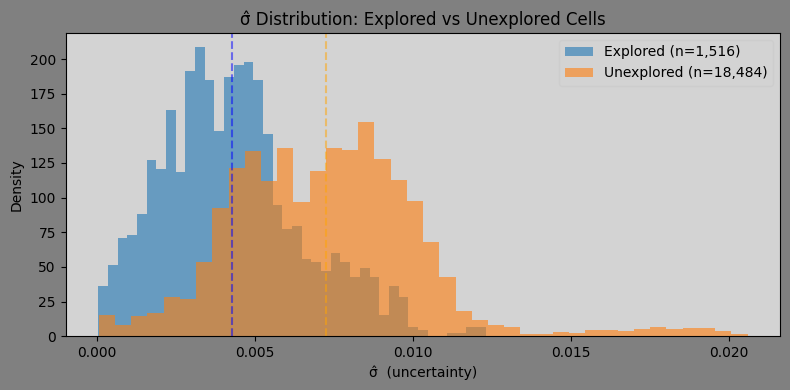

In [11]:
# Compute σ̂ for explored vs unexplored cells across the full grid
explored_sigma = full_grid.filter(pl.col("explored"))["sigma_hat"]
unexplored_sigma = full_grid.filter(~pl.col("explored"))["sigma_hat"]

# Convert to numpy for statistics
explored_sigma_np = explored_sigma.to_numpy()
unexplored_sigma_np = unexplored_sigma.to_numpy()

ratio = unexplored_sigma_np.mean() / explored_sigma_np.mean() if explored_sigma_np.mean() > 0 else float('inf')

print(f"Explored cells:   σ̂ mean = {explored_sigma_np.mean():.6f}  ± {explored_sigma_np.std():.6f}")
print(f"Unexplored cells: σ̂ mean = {unexplored_sigma_np.mean():.6f}  ± {unexplored_sigma_np.std():.6f}")
print(f"Ratio (unexplored / explored): {ratio:.2f}x")
print(f"Target: ≥ 2.0x  →  {'✓ PASS' if ratio >= 2.0 else '✗ FAIL — need higher tree diversity'}")

# Histogram comparison
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(explored_sigma_np, bins=40, alpha=0.6, density=True, label=f"Explored (n={len(explored_sigma_np):,})")
ax.hist(unexplored_sigma_np, bins=40, alpha=0.6, density=True, label=f"Unexplored (n={len(unexplored_sigma_np):,})")
ax.axvline(explored_sigma_np.mean(), color='blue', linestyle='--', alpha=0.5)
ax.axvline(unexplored_sigma_np.mean(), color='orange', linestyle='--', alpha=0.5)
ax.set_xlabel("σ̂  (uncertainty)")
ax.set_ylabel("Density")
ax.set_title("σ̂ Distribution: Explored vs Unexplored Cells")
ax.legend()
plt.tight_layout()
plt.show()

## Exploration Saturation Metric (ESM)

$$\text{ESM} = \frac{\mu_{\text{best, observed}}}{\hat{\mu}_{\text{max}} + \beta \cdot \hat{\sigma}_{\text{max}}} \times 100\%$$

- **Numerator** — best score actually seen in completed runs
- **Denominator** — max UCB across the entire grid (explored + unexplored)

A higher ESM means the sub-space is more saturated. 99.99% (4 nines) is the suggested stop threshold.

In [15]:
mu_best_observed = explored_dataframe[f"observed_{target_metric}"].max()

# UCB of the best cell across the entire grid (explored + unexplored)
best_ucb_idx  = full_grid["ucb"].arg_max()
mu_hat_max    = full_grid["mu_hat"][best_ucb_idx]
sigma_hat_max = full_grid["sigma_hat"][best_ucb_idx]
ucb_max       = mu_hat_max + beta * sigma_hat_max

esm = (mu_best_observed / ucb_max) * 100

# Count "nines" after the decimal
nines = 0
while (esm / 100) >= 9 * (10 ** (-nines - 1)) + (1 - 10 ** (-nines)):
    nines += 1
    if nines > 10:
        break

print(f"Best observed score (μ_best): {mu_best_observed:.6f}")
print(f"Best grid UCB:        μ̂={mu_hat_max:.6f}  σ̂={sigma_hat_max:.6f}  UCB={ucb_max:.6f}")
print()
print(f"ESM = {esm:.6f}%  ({nines} nines)")

thresholds = [(99.99, "4 nines — essentially saturated, move on"),
              (99.9,  "3 nines — marginal gain remaining"),
              (99.0,  "2 nines — modest gain remaining"),
              (90.0,  "1 nine  — substantial gain likely remaining")]
for threshold, label in thresholds:
    if esm >= threshold:
        print(f"  → {label}")
        break
else:
    print("  → Below 90% — early exploration stage")


Best observed score (μ_best): 0.050782
Best grid UCB:        μ̂=0.047743  σ̂=0.006570  UCB=0.054313

ESM = 93.498064%  (1 nines)
  → 1 nine  — substantial gain likely remaining


## Coverage at Percentile

$$\text{Coverage}_{p} = \frac{|\{x \in \text{explored} : \hat{\mu}(x) \geq p\text{-th percentile}\}|}{|\{x \in \text{all} : \hat{\mu}(x) \geq p\text{-th percentile}\}|}$$

Using p=75: *"what fraction of the top-25% predicted configurations have been tried?"*

In [16]:
def coverage_at_percentile(grid: pl.DataFrame, p: float = 75.0) -> float:
    """Fraction of top-(100-p)% predicted configs that have been explored."""
    threshold = np.percentile(grid["mu_hat"].to_numpy(), p)
    top_cells = grid.filter(pl.col("mu_hat") >= threshold)
    return 100.0 * top_cells["explored"].sum() / len(top_cells)

for p in [50, 75, 90, 95]:
    cov = coverage_at_percentile(full_grid, p)
    print(f"Coverage at p={p:2d}  (top {100-p:2d}% predicted configs):  {cov:.2f}%")


Coverage at p=50  (top 50% predicted configs):  9.00%
Coverage at p=75  (top 25% predicted configs):  13.14%
Coverage at p=90  (top 10% predicted configs):  16.75%
Coverage at p=95  (top  5% predicted configs):  22.40%


## Stop Condition & Top Unexplored Configurations

Stop exploring this sub-space when **both** hold:
- ESM ≥ 99.9% (3 nines)
- Coverage at p=75 ≥ 80%

Also display the top unexplored cells ranked by UCB — these are the next best candidates to run.

In [17]:
ESM_STOP_THRESHOLD      = 99.9   # 3 nines
COVERAGE_STOP_THRESHOLD = 80.0   # percent
COVERAGE_PERCENTILE     = 75

coverage_75 = coverage_at_percentile(full_grid, COVERAGE_PERCENTILE)

esm_met      = esm >= ESM_STOP_THRESHOLD
coverage_met = coverage_75 >= COVERAGE_STOP_THRESHOLD
should_stop  = esm_met and coverage_met

print("=" * 50)
print(f"  ESM:          {esm:.4f}%   (threshold ≥ {ESM_STOP_THRESHOLD}%)  {'✓' if esm_met else '✗'}")
print(f"  Coverage@75:  {coverage_75:.2f}%    (threshold ≥ {COVERAGE_STOP_THRESHOLD}%)  {'✓' if coverage_met else '✗'}")
print("=" * 50)
print(f"  → {'STOP — sub-space saturated.' if should_stop else 'CONTINUE exploration.'}")
print("=" * 50)


  ESM:          93.4981%   (threshold ≥ 99.9%)  ✗
  Coverage@75:  13.14%    (threshold ≥ 80.0%)  ✗
  → CONTINUE exploration.


In [18]:
# Top unexplored configurations ranked by UCB
top_unexplored = (
    unexplored_dataframe
    .sort("ucb", descending=True)
    .head(20)
    .select([*feature_names, "mu_hat", "sigma_hat", "ucb"])
)
top_unexplored


embedding_dimension,shuffle,l1_regularization,l2_regularization,embedding_dropout_rate,mu_hat,sigma_hat,ucb
i64,f64,f64,f64,f64,f64,f64,f64
512,0.0,0.0000001,0.0000001,0.2,0.047743,0.00657,0.054313
512,0.0,0.0000001,0.0000001,0.1,0.047819,0.006405,0.054225
256,0.0,0.0000001,0.0000001,0.2,0.047353,0.006802,0.054155
1024,0.0,0.0000001,0.0000001,0.2,0.047124,0.006933,0.054056
256,0.0,0.0000001,0.0000001,0.1,0.04743,0.006608,0.054039
1024,0.0,0.0000001,0.0000001,0.1,0.047196,0.006797,0.053993
128,0.0,0.0000001,0.0000001,0.2,0.047358,0.00606,0.053417
128,0.0,0.0000001,0.0000001,0.1,0.047434,0.005831,0.053264
256,1.0,0.0000001,0.0000001,0.2,0.04549,0.007227,0.052718
